# STA 142A Final Project
Ani, Sohan, Sumit

# Import Packages

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import xgboost as xgb
from lightgbm import LGBMClassifier

# Explore Data

In [13]:
train_data = pd.read_csv("./winter-2026-machine-learning-competition/train.csv")
train_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,Label,Time
0,-0.088213,-0.023162,0.668907,-0.024412,-0.135344,1.127264,-0.047674,0.062453,0.612125,-0.170337,...,-0.388204,-0.107234,0.096572,-0.374472,-0.316826,0.511417,-0.032564,0.598193,0,0.000000
1,-0.107234,0.133155,0.100388,-0.417936,0.029599,0.222118,-0.049331,0.054844,-0.351857,-0.167496,...,-0.102559,0.109613,-0.702298,-0.357710,0.347009,-0.072820,-0.032632,0.010755,0,0.000000
2,-0.088388,-0.614218,1.247813,-0.431052,-0.203786,2.031199,-0.029258,0.145734,-1.533352,-0.165292,...,0.059467,0.927852,-1.306390,-0.241200,-0.205855,-0.263291,-0.031625,1.513913,0,0.006367
3,-0.110742,0.413393,1.276252,-0.426834,-0.163922,0.527130,-0.038153,-0.144683,1.204301,-0.089479,...,0.095536,-0.134940,0.244121,-0.336443,1.046677,0.858741,-0.018805,0.279826,0,0.012735
4,-0.151862,0.659004,1.106422,-0.408339,0.395609,1.074282,-0.008887,-2.183966,0.962959,0.054305,...,0.435762,0.064861,-1.244456,-0.145681,-0.017092,-3.876938,0.320805,0.163122,0,0.044572


In [14]:
train_data.isna().sum().sum()

np.int64(0)

In [15]:
train_data.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,Label,Time
count,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,...,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000,170889.000000
mean,-0.003126,0.000575,0.001281,-0.001328,0.001463,-0.000154,-0.003027,-0.000725,0.003121,0.000590,...,0.000858,0.000305,-0.000120,0.000092,0.000093,-0.000799,-0.001390,0.352226,0.001756,603.931330
std,0.949185,1.094614,1.000157,0.988794,0.563124,1.000487,0.473843,1.142297,1.000447,0.958975,...,1.035132,1.159463,0.999512,1.053395,1.001563,1.000351,1.089882,0.995039,0.041862,302.704969
min,-0.170286,-298.631688,-1.543072,-0.464469,-21.770639,-1.350086,-0.049532,-365.120125,-1.535848,-0.171530,...,-0.454879,-385.819543,-2.032996,-0.398716,-30.169151,-4.146052,-0.032697,0.000000,0.000000,0.000000
25%,-0.147017,-0.266932,-0.986589,-0.425726,-0.282175,-0.847391,-0.047602,-0.109801,-0.881865,-0.165083,...,-0.399046,-0.160195,-0.728323,-0.353039,-0.635927,-0.325444,-0.032472,0.022549,0.000000,344.799266
50%,-0.106038,0.040517,0.163920,-0.314924,-0.018221,-0.187614,-0.039309,0.019200,-0.046010,-0.134318,...,-0.206197,-0.005712,0.043402,-0.235324,-0.017313,-0.030504,-0.031583,0.087958,0.000000,539.621580
75%,-0.006983,0.379365,0.984720,-0.000586,0.255979,0.714915,-0.020509,0.190696,0.878547,-0.046064,...,0.125965,0.156441,0.810210,0.030919,0.571410,0.340023,-0.026585,0.308212,0.000000,887.903795
max,141.057264,8.907386,1.276595,65.516377,12.562234,2.076196,62.764832,9.918374,1.632684,87.298782,...,102.790782,18.693996,1.959124,155.130717,4.677230,4.074254,343.779527,78.588363,1.000000,1100.204531


We're working with imbalanced data, and our key metric is ROC_AUC

Let's recall that ROC is TPR vs. FPR, and that tells us how good our model is at distinguishing between classes.

## EDA Visualizations

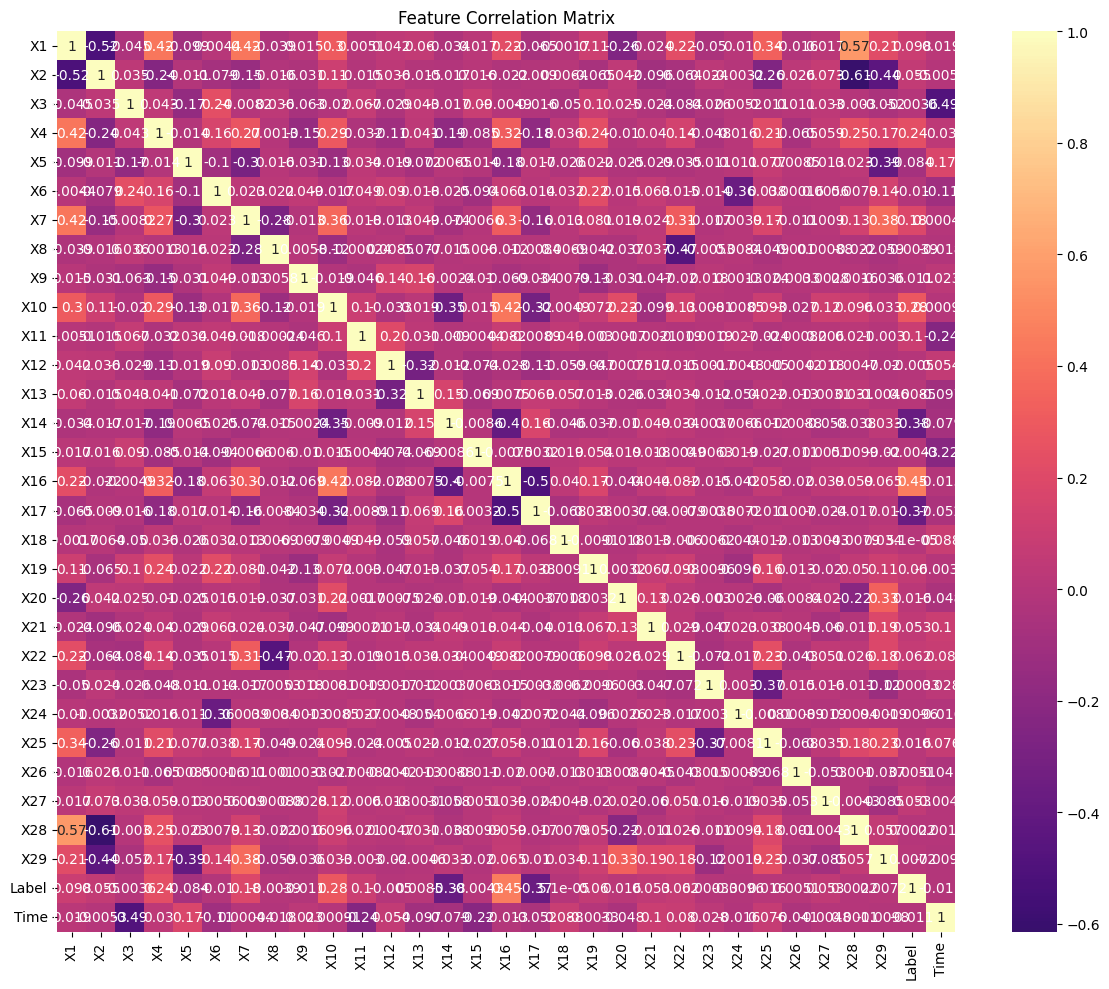

Correlation with Label:
Label    1.000000
X16      0.452463
X10      0.284125
X4       0.235644
X7       0.181938
Name: Label, dtype: float64


In [16]:
plt.figure(figsize=(12, 10))
correlation = train_data.corr()
sns.heatmap(correlation, annot=True, cmap='magma', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

#let's see what has the highest correlation with our Y
print("Correlation with Label:")
print(correlation['Label'].sort_values(ascending=False)[:5])

Not the most promising, but from what we observe, there is significant multicollinearity between our features. We will need to regularize or do something to prevent overfitting. Using all or a lot of features will jeapordize our model when predicting. It won't generalize well.

Off the top, we can simply drop our features with the 5 weakest correlations with the Label. 

In [17]:
print(correlation['Label'].abs().sort_values(ascending=True)[:10])

X18    0.000051
X23    0.000331
X28    0.002165
X3     0.003566
X8     0.003886
X15    0.004340
X12    0.004956
X26    0.005105
X29    0.007190
X13    0.008462
Name: Label, dtype: float64


No wait, let's let our models select with **feature importance**

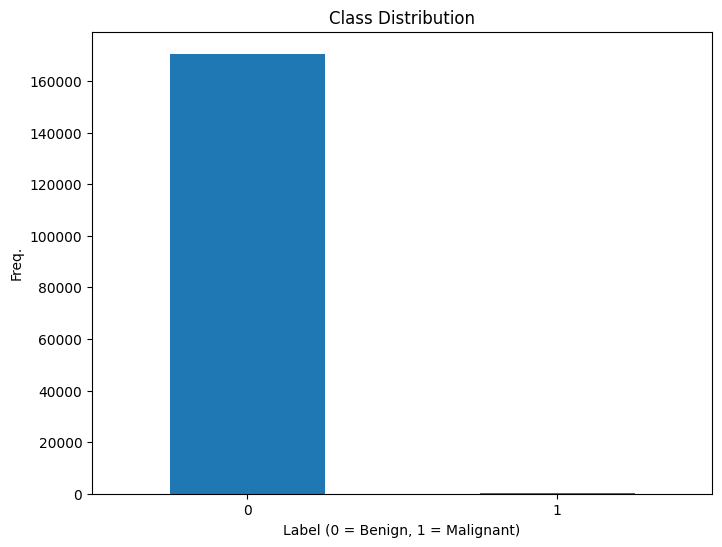

Label
0    0.998244
1    0.001756
Name: proportion, dtype: float64


In [18]:
#bar plot. check for class imbalance
plt.figure(figsize=(8, 6))
train_data['Label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Label (0 = Benign, 1 = Malignant)')
plt.ylabel('Freq.')
plt.xticks(rotation=0)
plt.show()

# percentages
print(train_data['Label'].value_counts(normalize=True))

Our data is heavily imbalanced, but this is the nature of the challenge. 

What we can use to our advantage:
- Stratifying 
- StratifiedKfold
- SMOTE?

# Training Models

## Option 1 : Currrent Random Forest

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

In [10]:
#it's all train data
X = train_data.drop('Label',axis=1)
y = train_data['Label'].to_numpy()

In [21]:
#Stratified K-fold CV
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
rf = RandomForestClassifier(class_weight='balanced',n_estimators=200,random_state=42) #don't need to normalize for an RF
cv_scores = cross_val_score(rf,X,y,cv=cv,scoring='roc_auc')
print(f"ROC AUC's for each fold: {cv_scores}")
print(f"CV ROC_AUC: {cv_scores.mean()}")

rf.fit(X, y)

ROC AUC's for each fold: [0.97188483 0.95451692 0.93786857 0.91144508 0.94688498]
CV ROC_AUC: 0.944520078658288


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## Option 2 : Logistic Regression with L1 Penalty 
- We will need to scale the numeric data though

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [23]:
pipeline_lrl1 = Pipeline([
    ("scaler",StandardScaler()),
    ("classifier",LogisticRegression(penalty='l1',class_weight='balanced',solver="saga",max_iter=1000))
])

#still using 5-fold cv from earlier
cv_lrl1 = cross_val_score(pipeline_lrl1,X,y,cv=cv,scoring="roc_auc")
print(f"ROC AUC's for each fold: {cv_lrl1}")
print(f"CV ROC_AUC: {cv_lrl1.mean()}")

pipeline_lrl1.fit(X,y)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

ROC AUC's for each fold: [0.99028763 0.96706968 0.96122917 0.94611642 0.95674786]
CV ROC_AUC: 0.9642901503479564


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    penalty='l1', solver='saga'))])

Ok so Logistic Regression with L1 Penalty now has a 96% CV ROC_AUC. And RandomForest with a 94.4% CV ROC_AUC. Let's see what our submissions give us. 

# Deploy on test set and submit predcitions

In [24]:
test_data = pd.read_csv("./winter-2026-machine-learning-competition/test.csv")
X_test_final = test_data.drop(columns=["id"])

In [25]:
y_test_proba_rf = rf.predict_proba(X_test_final)[:, 1]
y_test_proba_lrl1 = pipeline_lrl1.predict_proba(X_test_final)[:,1]

In [27]:
submission_rf = pd.DataFrame({"id":test_data.index,"Label":y_test_proba_rf})
submission_lrl1 = pd.DataFrame({"id":test_data.index,"Label":y_test_proba_lrl1})

submission_rf.to_csv('submission_rf.csv',index=False)
submission_rf.to_csv("submission_lrl1.csv",index=False)

# Below is Sumit work with XGBoost

XGBoost

In [14]:

# Compute scale_pos_weight to handle class imbalance (ratio of negatives to positives)
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')
print(f"XGBoost ROC AUC per fold: {xgb_cv_scores}")
print(f"XGBoost CV ROC_AUC: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

# Fit on full training data and generate submission
xgb_model.fit(X, y)
y_test_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

submission_xgb = pd.DataFrame({"id": test_data.index, "Label": y_test_proba_xgb})
submission_xgb.to_csv('submission_XGBoost.csv', index=False)
submission_xgb.head()


C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:06:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:06:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:07:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } 

XGBoost ROC AUC per fold: [0.99437003 0.97214325 0.98085224 0.95314839 0.97232807]
XGBoost CV ROC_AUC: 0.9746 (+/- 0.0134)


C:\Users\sumit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:07:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,id,Label
0,0,6.346436e-07
1,1,4.516120e-06
2,2,1.101265e-05
3,3,1.650136e-05
4,4,6.193303e-06
